<a href="https://colab.research.google.com/github/AndreiaHenrique/bank_churn_project/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Exploratory Data Analysis (EDA)

**Project:** Bank Customer Churn Prediction  
**Dataset:** [Churn Modelling Dataset (Kaggle)](https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling)  
**Author:** Andreia Henrique

---

## Objectives of this notebook
1. Understand the structure and quality of the dataset.
2. Profile each variable (univariate analysis).
3. Study the relationship between every feature and the target `Exited` (bivariate analysis).
4. Explore multivariate interactions and customer segments.
5. Confirm patterns through **statistical tests** (Chi-square, Mann–Whitney U).
6. Produce a list of insights that will guide feature engineering in notebooks `02` and `03`.


## 1. Setup

In [1]:
# Standard libs
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot configuration
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

PALETTE = ["#2E86AB", "#E63946"]   # 0 = retained, 1 = churned
sns.set_palette(PALETTE)

RANDOM_STATE = 42


## 2. Load the data

> **Tip (Colab):** upload `Churn_Modelling.csv` to your session or mount Google Drive.  
> Alternatively, install the Kaggle API and download it programmatically:
> ```python
> !pip install -q kaggle
> !kaggle datasets download -d shrutimechlearn/churn-modelling -p data --unzip
> ```


In [5]:
DATA_PATH = "Churn_Modelling.csv"   # adjust if needed

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Data quality overview

In [6]:
print("Dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicated rows:", df.duplicated().sum())
print("\nUnique CustomerId:", df["CustomerId"].nunique(), "of", len(df))


Dtypes:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicated rows: 0

Unique CustomerId: 10000 of 10000


In [7]:
# Drop identifiers that carry no predictive signal
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
HasCrCard,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
IsActiveMember,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0
EstimatedSalary,10000.0,NaN,NaN,NaN,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


## 4. Target variable: `Exited`

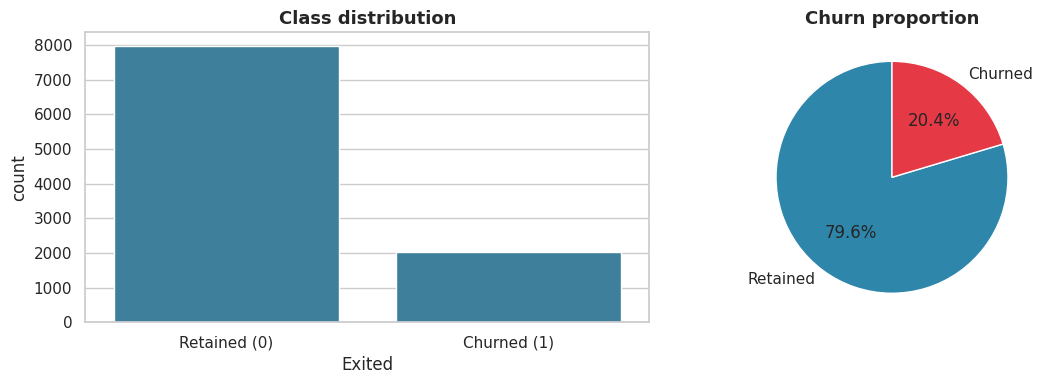

Global churn rate: 20.37%
Imbalance ratio  : 1 : 3.91


In [8]:
churn_counts = df["Exited"].value_counts()
churn_rate = df["Exited"].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Exited", data=df, ax=ax[0])
ax[0].set_title("Class distribution")
ax[0].set_xticklabels(["Retained (0)", "Churned (1)"])

ax[1].pie(churn_counts, labels=["Retained", "Churned"], autopct="%1.1f%%",
          colors=PALETTE, startangle=90, wedgeprops={"edgecolor": "white"})
ax[1].set_title("Churn proportion")
plt.tight_layout(); plt.show()

print(f"Global churn rate: {churn_rate:.2%}")
print(f"Imbalance ratio  : 1 : {churn_counts[0] / churn_counts[1]:.2f}")


> The dataset is **imbalanced** (~20% positive class). We will need to address it
> in the classification notebook with `class_weight` or resampling (SMOTE).

## 5. Univariate analysis

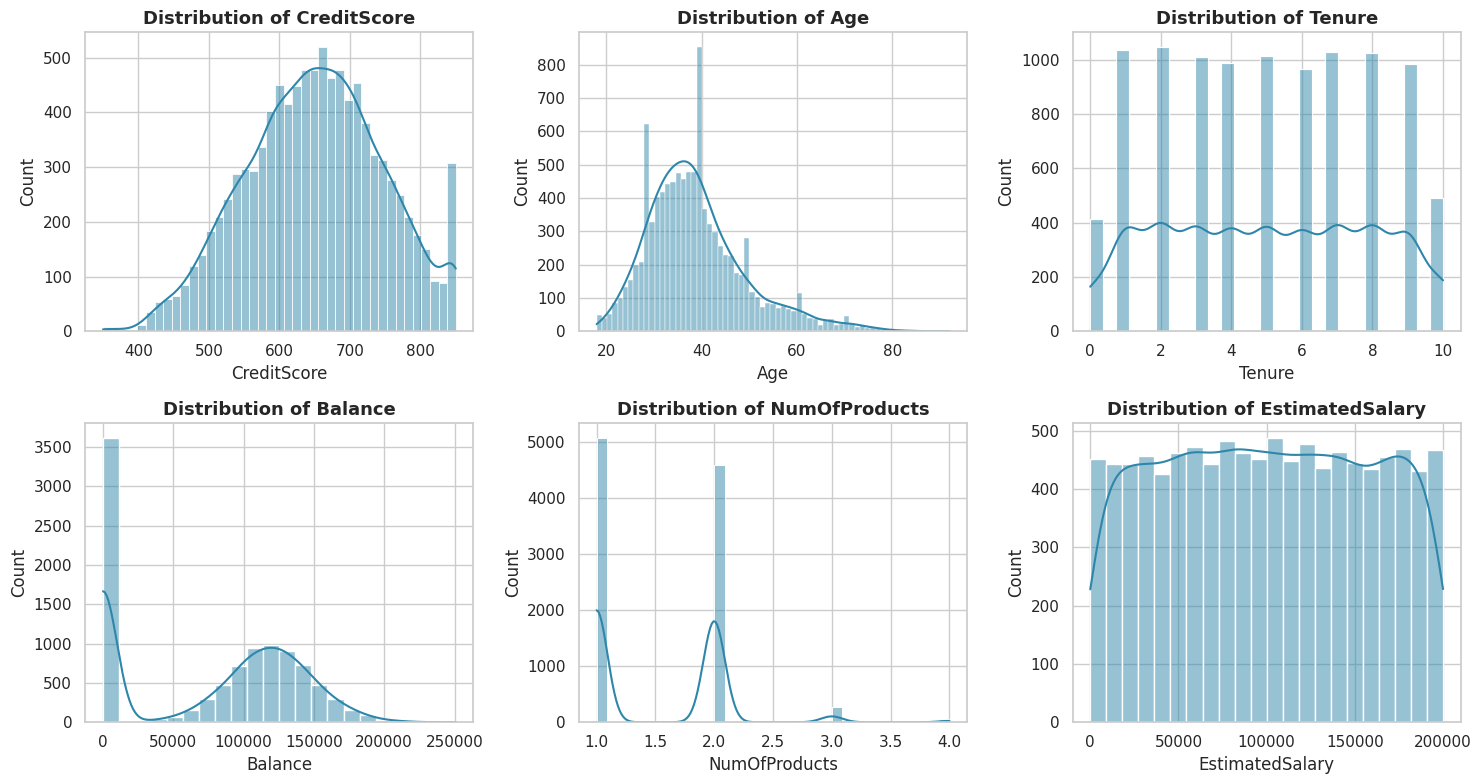

In [9]:
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance",
                "NumOfProducts", "EstimatedSalary"]
categorical_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

# --- numeric distributions ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2E86AB")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout(); plt.show()


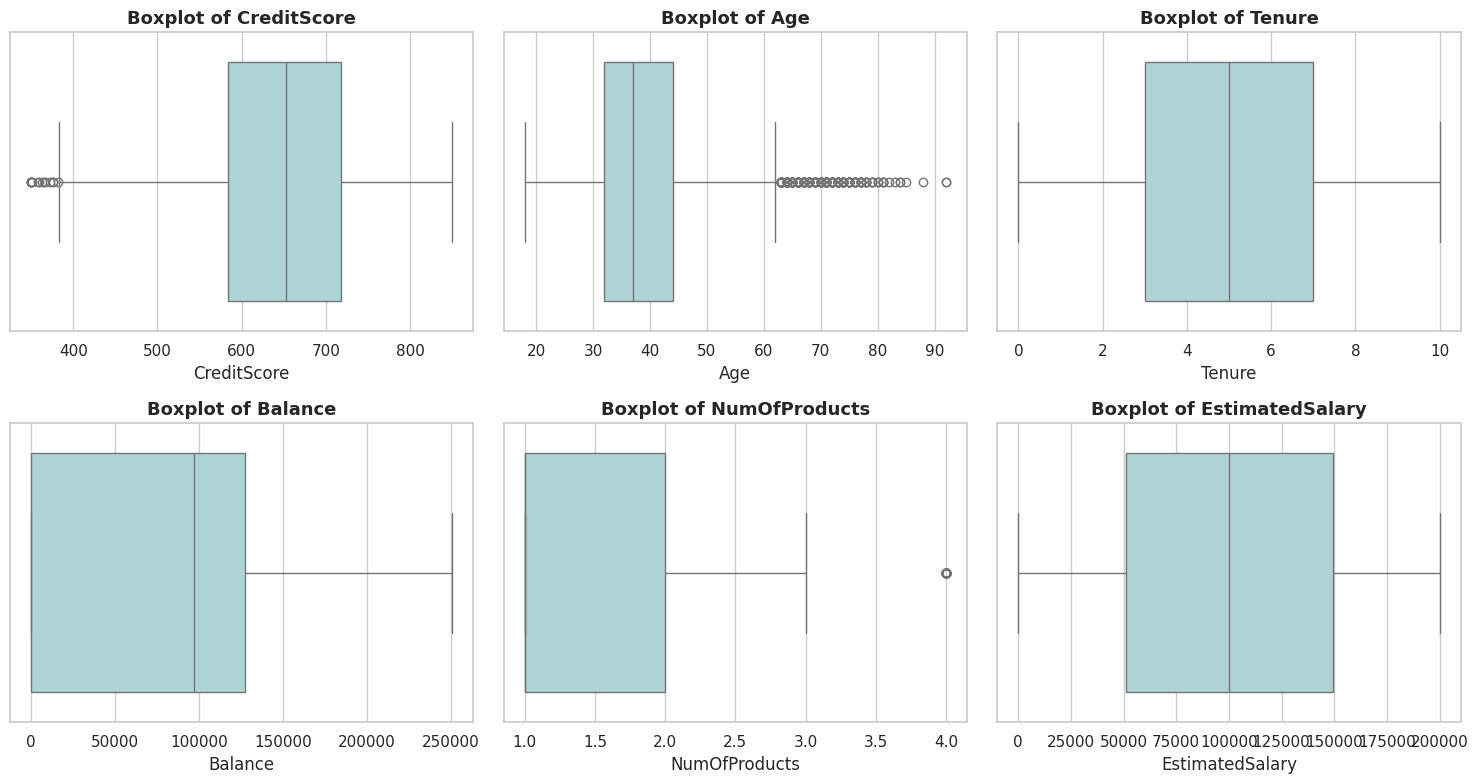

In [10]:
# --- numeric outliers via boxplots ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(x=df[col], ax=ax, color="#A8DADC")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout(); plt.show()


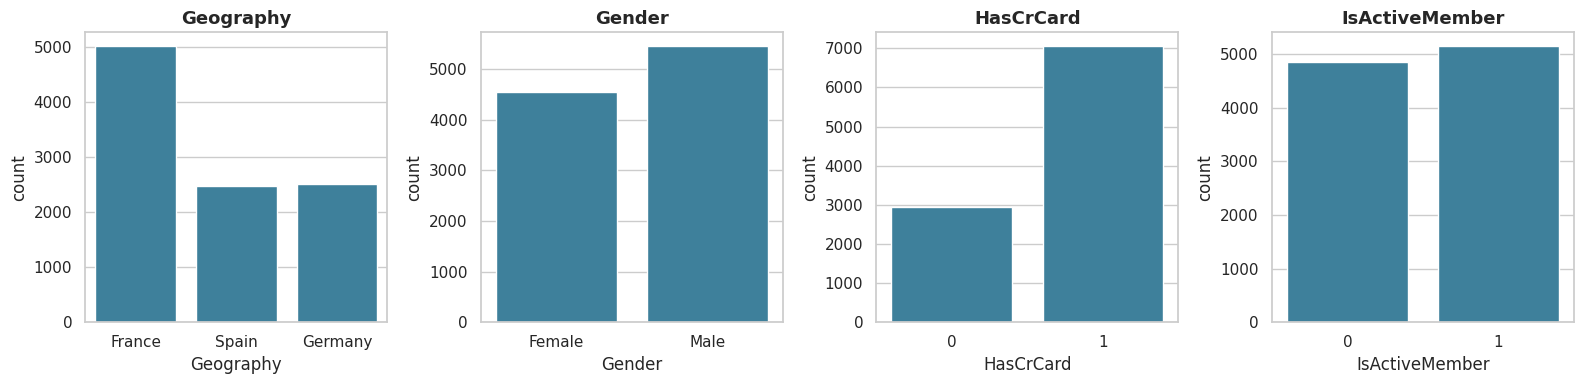

In [11]:
# --- categorical distributions ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, categorical_cols):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f"{col}")
plt.tight_layout(); plt.show()


## 6. Bivariate analysis vs. `Exited`

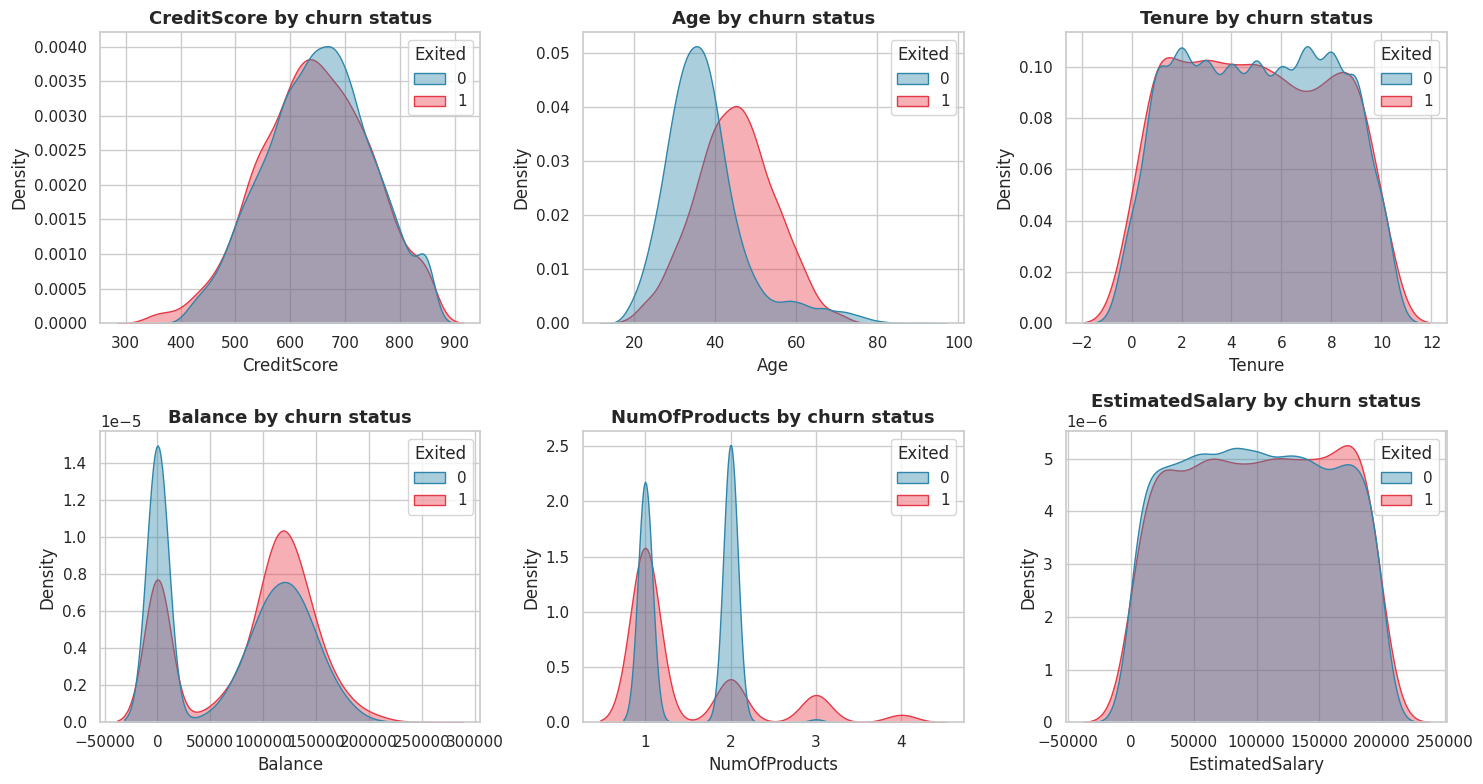

In [12]:
# Numeric features vs target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.kdeplot(data=df, x=col, hue="Exited", common_norm=False,
                fill=True, alpha=0.4, ax=ax, palette=PALETTE)
    ax.set_title(f"{col} by churn status")
plt.tight_layout(); plt.show()


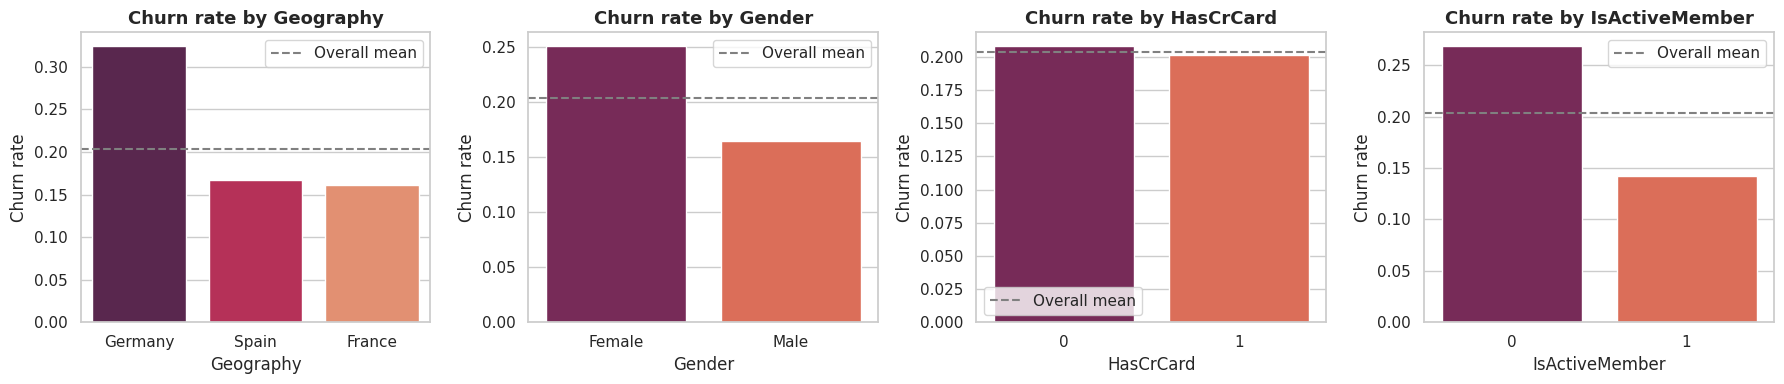

In [13]:
# Categorical features vs target — churn rate
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, categorical_cols):
    rate = df.groupby(col)["Exited"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax,
                palette="rocket")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.axhline(df["Exited"].mean(), ls="--", color="grey",
               label="Overall mean")
    ax.legend()
plt.tight_layout(); plt.show()


## 7. Customer segments

          churn_rate  n_customers
AgeGroup                         
18-30       0.075203         1968
31-40       0.120872         4451
41-50       0.339655         2320
51-60       0.562108          797
60+         0.247845          464


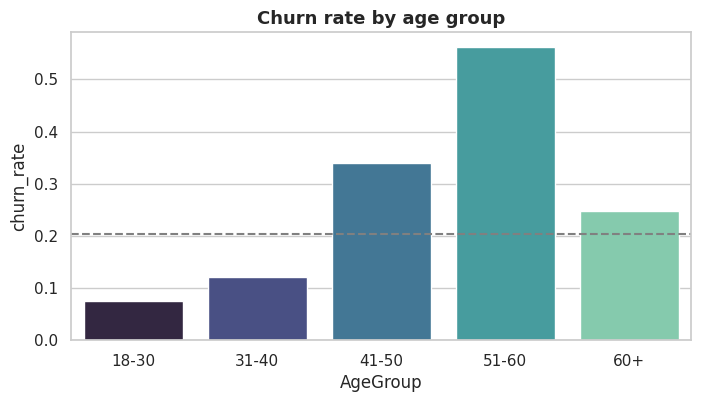

In [14]:
# 7.1 — Age groups
df["AgeGroup"] = pd.cut(df["Age"], bins=[17, 30, 40, 50, 60, 100],
                        labels=["18-30", "31-40", "41-50", "51-60", "60+"])

seg = df.groupby("AgeGroup")["Exited"].agg(["mean", "count"]).rename(
    columns={"mean": "churn_rate", "count": "n_customers"})
print(seg)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=seg.index, y=seg["churn_rate"], ax=ax, palette="mako")
ax.axhline(df["Exited"].mean(), ls="--", color="grey")
ax.set_title("Churn rate by age group")
plt.show()


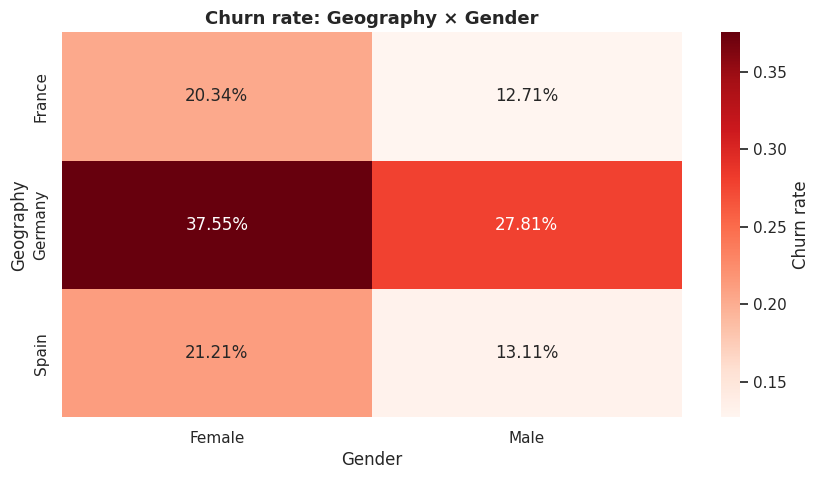

In [15]:
# 7.2 — Geography × Gender interaction
pivot = df.pivot_table(index="Geography", columns="Gender",
                       values="Exited", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".2%", cmap="Reds",
            cbar_kws={"label": "Churn rate"})
plt.title("Churn rate: Geography × Gender")
plt.show()


                   mean  count
NumOfProducts                 
1              0.277144   5084
2              0.075817   4590
3              0.827068    266
4              1.000000     60


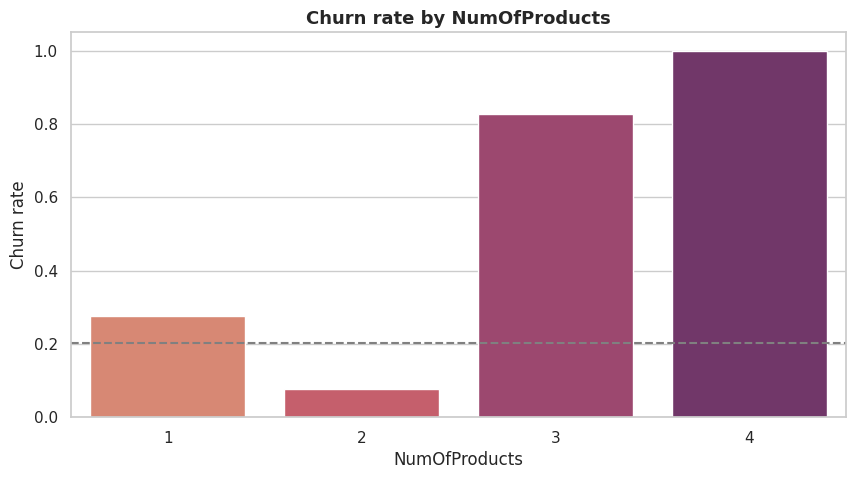

In [16]:
# 7.3 — NumOfProducts effect
prod = df.groupby("NumOfProducts")["Exited"].agg(["mean", "count"])
print(prod)

sns.barplot(x=prod.index, y=prod["mean"], palette="flare")
plt.axhline(df["Exited"].mean(), ls="--", color="grey")
plt.title("Churn rate by NumOfProducts")
plt.ylabel("Churn rate"); plt.show()


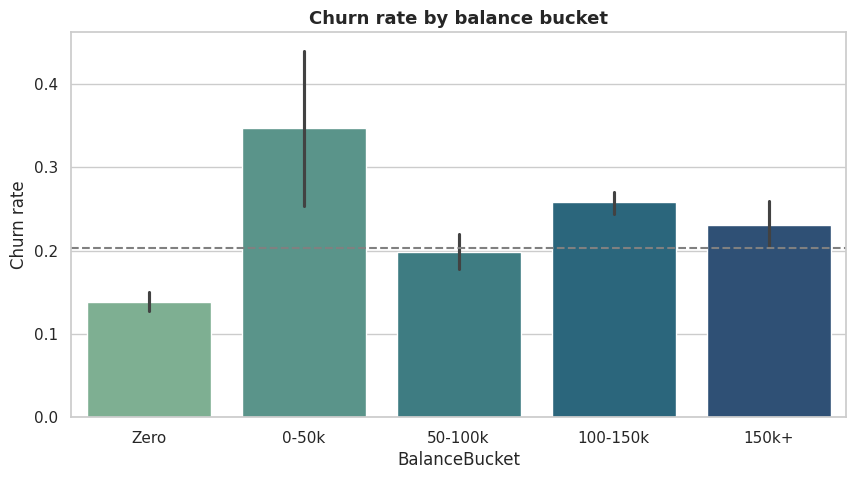

In [17]:
# 7.4 — Balance regimes
df["BalanceBucket"] = pd.cut(df["Balance"],
    bins=[-1, 0, 50_000, 100_000, 150_000, 300_000],
    labels=["Zero", "0-50k", "50-100k", "100-150k", "150k+"])

sns.barplot(x="BalanceBucket", y="Exited", data=df, palette="crest")
plt.axhline(df["Exited"].mean(), ls="--", color="grey")
plt.title("Churn rate by balance bucket")
plt.ylabel("Churn rate"); plt.show()


## 8. Correlation & associations

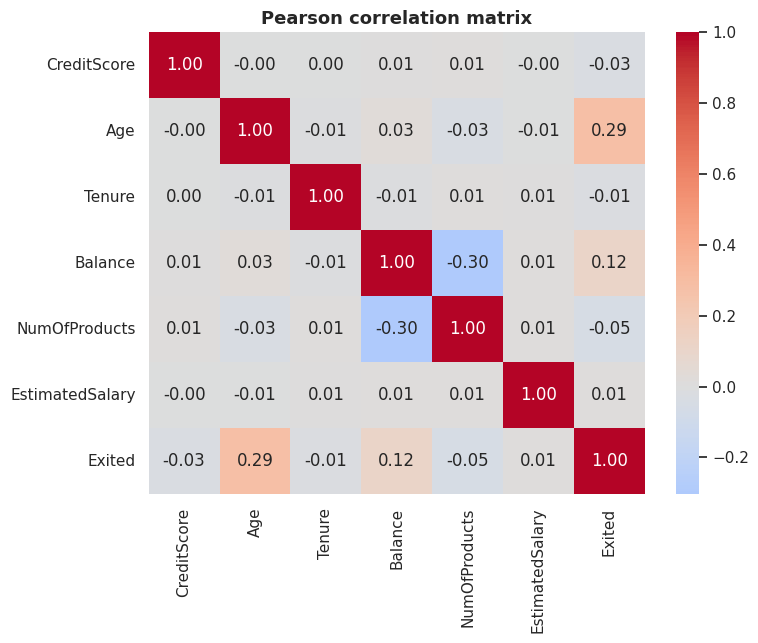

In [18]:
# Pearson correlation for numeric features
corr = df[numeric_cols + ["Exited"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson correlation matrix")
plt.show()


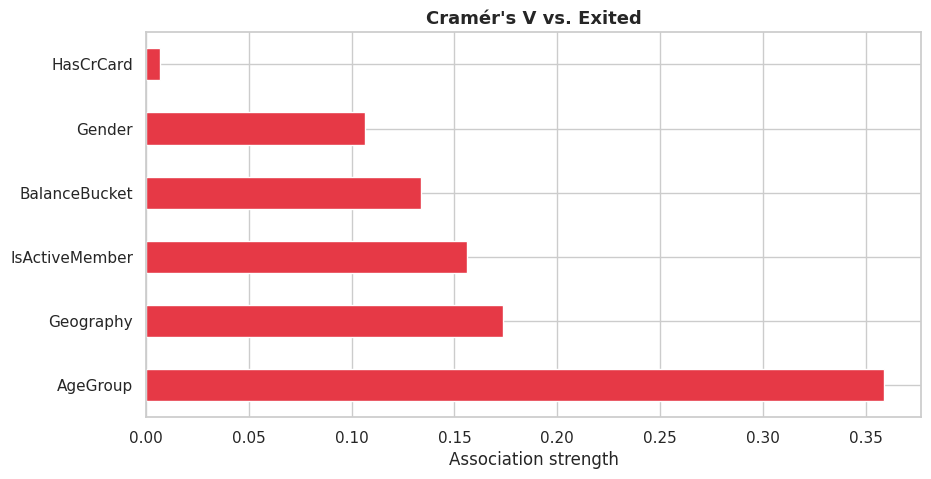

In [19]:
# Cramér's V for categorical associations
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_features = categorical_cols + ["AgeGroup", "BalanceBucket"]
v_scores = {c: cramers_v(df[c], df["Exited"]) for c in cat_features}
pd.Series(v_scores).sort_values(ascending=False).plot(
    kind="barh", color="#E63946")
plt.title("Cramér's V vs. Exited"); plt.xlabel("Association strength")
plt.show()


## 9. Statistical tests

In [20]:
# 9.1 — Chi-square for categorical features vs. target
print("Chi-square tests (H0: independent of Exited)\n")
for col in cat_features:
    table = pd.crosstab(df[col], df["Exited"])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    flag = "*** significant" if p < 0.05 else "not significant"
    print(f"  {col:<15s}  chi2={chi2:8.2f}  p={p:.4g}  {flag}")


Chi-square tests (H0: independent of Exited)

  Geography        chi2=  301.26  p=3.83e-66  *** significant
  Gender           chi2=  112.92  p=2.248e-26  *** significant
  HasCrCard        chi2=    0.47  p=0.4924  not significant
  IsActiveMember   chi2=  242.99  p=8.786e-55  *** significant
  AgeGroup         chi2= 1289.70  p=5.702e-278  *** significant
  BalanceBucket    chi2=  178.60  p=1.49e-37  *** significant


In [21]:
# 9.2 — Mann-Whitney U for numeric features (non-parametric, robust)
print("Mann-Whitney U (H0: same distribution across churn classes)\n")
for col in numeric_cols:
    g0 = df.loc[df["Exited"] == 0, col]
    g1 = df.loc[df["Exited"] == 1, col]
    stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    flag = "*** significant" if p < 0.05 else "not significant"
    print(f"  {col:<18s}  U={stat:11.0f}  p={p:.4g}  {flag}")


Mann-Whitney U (H0: same distribution across churn classes)

  CreditScore         U=    8381083  p=0.01987  *** significant
  Age                 U=    4345982  p=3.21e-230  *** significant
  Tenure              U=    8272056  p=0.1622  not significant
  Balance             U=    6849444  p=1.116e-28  *** significant
  NumOfProducts       U=    9390006  p=5.275e-36  *** significant
  EstimatedSalary     U=    7969863  p=0.2271  not significant


## 10. Key takeaways

* **Age** is the strongest numeric driver: customers between 45 and 60 churn 2-3× more than the average.
* **Geography** matters: Germany has the highest churn rate even though customers there hold larger balances.
* **Gender**: females churn noticeably more than males.
* **NumOfProducts**: clients with 3-4 products almost always leave (~80%-100%). The cross-selling strategy is back-firing.
* **IsActiveMember** has a strong protective effect.
* **Tenure, HasCrCard, EstimatedSalary** show weak (statistically non-significant) relations with churn.
* The dataset is **imbalanced** (~20% positives) → use `class_weight="balanced"` and/or SMOTE in modelling.

These insights motivate the feature-engineering choices used in `03_Classification.ipynb`
(e.g. `Risk_Score`, `Germany_HighBalance`, `Too_Many_Products`, `Inactive_MultiProduct`).
